# Diversity User Study Results Analysis

This notebook analyzes telemetry and accuracy from the **landing_page_diversity** experiment, comparing **list** (raw_outputs) vs **graph** interfaces for the diversity comparison task.

**Filtering**: Only includes participants who visited the diversity landing page. Participants may have rows from that page and from the vis pages (graph/raw_outputs) they opened.

**Metrics**:
- **Accuracy**: % of correct answers (which set has higher diversity: orange vs blue)
- **Time**: Time spent per question, with loading time subtracted (from `graph_vis_loaded` telemetry for graph; list has no loading event so we use 0)

## 1. Setup & Load Data

In [766]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import numpy as np
from pathlib import Path
from scipy import stats

# Paths: works if run from repo root or from user_study_results/diversity/
DATA_DIR = Path("user_study_results/diversity")
if not DATA_DIR.exists():
    DATA_DIR = Path("diversity")
if not DATA_DIR.exists():
    DATA_DIR = Path(".")

OUTPUTS_PATH = DATA_DIR / "user_study_logging - outputs.csv"
df = pd.read_csv(OUTPUTS_PATH)

def safe_parse_json(s):
    if pd.isna(s) or not isinstance(s, str):
        return []
    try:
        return json.loads(s)
    except json.JSONDecodeError:
        return []

print(f"Loaded {len(df)} rows")
print(f"Columns: {list(df.columns)}")
print(f"Interfaces: {df['Interface'].value_counts().to_dict()}")

Loaded 3703 rows
Columns: ['Timestamp', 'Participant ID', 'Interface', 'Telemetry']
Interfaces: {'landing_page_single_distribution': 1393, 'raw_outputs': 841, 'graph': 826, 'landing_page_diversity': 386, 'graph_untangle': 120, 'landing_page': 88, 'landing_page_compare_distributions': 49}


## 2. Filter to Diversity Study Participants

**Key**: Only include participants who ever visited `landing_page_diversity`. They will have rows from that page plus rows from graph/raw_outputs when they opened the vis in a new tab. We identify these participants and then keep ALL their rows (any Interface).

In [767]:
# Study end per participant: when they reach the final survey page (block_timer_elapsed block 2)
# Excludes everything after: no leavePage from graph/list/landing, no tab-closing events
def compute_end_ts_by_pid(df_subset):
    events = []
    seen = set()
    for _, row in df_subset.iterrows():
        pid = str(row.get('Participant ID', '')).strip() if pd.notna(row.get('Participant ID')) else ''
        if not pid:
            continue
        telemetry = safe_parse_json(row.get('Telemetry', ''))
        if not telemetry:
            continue
        interface = row.get('Interface', '')
        for evt in telemetry:
            ts = evt.get('timestamp')
            if ts is None:
                continue
            data = evt.get('data', {})
            key = (pid, evt.get('type'), ts, data.get('url', ''), data.get('block'), data.get('questionIndex'))
            if key in seen:
                continue
            seen.add(key)
            events.append({'pid': pid, 'ts': ts, 'type': evt.get('type'), 'data': data, 'interface': interface})
    end_ts_by_pid = {}
    for pid in set(e['pid'] for e in events):
        pid_evts = sorted([e for e in events if e['pid'] == pid], key=lambda x: x['ts'])
        for e in pid_evts:
            if e['type'] == 'block_timer_elapsed' and e.get('data', {}).get('block') == 2 and e.get('interface') == 'landing_page_diversity':
                end_ts_by_pid[pid] = e['ts']  # last occurrence if multiple; participants not in dict keep all events
    return end_ts_by_pid

end_ts_by_pid = compute_end_ts_by_pid(filtered_df)

Compute study end per participant: when they reach the final survey page (block_timer_elapsed block 2). Timeline cuts off there—no leavePage or other events from graph/list/landing shown after that.

In [768]:
# Toggle to exclude test user(s) whose PID contains any of these substrings
filter_test_user = True  # Set to False to include test users for debugging
TEST_PID_SUBSTRINGS = [
    "690a9d9bf662e714c2edc7df",   # known test user
    "{{%PROLIFIC_PID%}}",         # Prolific URL placeholder (unreplaced = test)
]

# Participants who went to landing_page_diversity (have at least one row with that Interface)
diversity_rows = df[df['Interface'] == 'landing_page_diversity']
valid_participant_ids = set(
    diversity_rows['Participant ID'].dropna().astype(str).str.strip()
) - {''}

# Exclude test user(s) when filter_test_user is True
if filter_test_user:
    valid_participant_ids = {pid for pid in valid_participant_ids
                            if not any(s in pid for s in TEST_PID_SUBSTRINGS)}

# Only use IDs that actually appear in landing_page_diversity rows (do not manually override)
# (for local testing - use startedAt from telemetry as session key)
# For now we strictly use Participant ID; empty-ID sessions are excluded

if not valid_participant_ids:
    print("WARNING: No participants with non-empty Participant ID in landing_page_diversity rows.")
    print("Include local test runs by uncommenting session-based logic, or ensure Prolific params are in the URL.")

filtered_df = df[df['Participant ID'].isin(valid_participant_ids)].copy()

if len(filtered_df) == 0 and valid_participant_ids:
    print("WARNING: No rows match these participant IDs. IDs must come from the data — do not manually override.")
elif len(filtered_df) == 0:
    print("WARNING: No diversity participants (all landing_page_diversity rows have empty Participant ID).")

print(f"Participants who visited landing_page_diversity: {len(valid_participant_ids)}")
print(f"Participant IDs: {valid_participant_ids}")
print(f"Filtered rows: {len(filtered_df)} (from {len(df)} total)")
print(f"By Interface:\n{filtered_df['Interface'].value_counts()}")

Participants who visited landing_page_diversity: 2
Participant IDs: {'6538149a1ceb9e0fadcc27f0_699f3276bd3c173adcb7e132_699f65e768ad99ce23758c30', '6942ca925990045ee2f424d3_699f3276bd3c173adcb7e132_699f65fc5db853cfb6f8f45a'}
Filtered rows: 60 (from 3703 total)
By Interface:
Interface
landing_page_diversity    30
graph                     17
raw_outputs               13
Name: count, dtype: int64


## 3. Parse Telemetry: Extract Answers and Loading Times

Parse the Telemetry JSON column to extract:
- **diversity_comparison_answer**: `correct`, `timeMs`, `visType` (raw_outputs=list, graph=graph)
- **graph_vis_loaded**: `timeSincePageLoadMs` — used to subtract loading time for graph answers

In [769]:
def extract_answers_and_loading(df_subset, end_ts_by_pid=None):
    """Extract diversity_comparison_answer events and graph_vis_loaded loading times.
    Deduplicates answers by (participant, block, questionIndex, url).
    For loading: uses only the FIRST (chronologically) graph_vis_loaded per (pid, url),
    and only retains load times for (pid, url) that appear in graph answers.
    So there are at most as many load times as there are unique graph answer views."""
    answers = []
    seen_answers = set()  # (pid, block, questionIndex, url)
    load_events = []  # (pid, url, timestamp, load_ms) - collect all, then take first per (pid,url)
    
    for _, row in df_subset.iterrows():
        pid = str(row.get('Participant ID', '')).strip() if pd.notna(row.get('Participant ID')) else ''
        telemetry = safe_parse_json(row.get('Telemetry', ''))
        if not telemetry:
            continue
        
        page_loads = [(e.get('timestamp'), e.get('data', {}).get('url', '')) for e in telemetry if e.get('type') == 'page_load']
        page_loads = [(t, u) for t, u in page_loads if t and u]
        
        for evt in telemetry:
            evt_type = evt.get('type')
            ts = evt.get('timestamp')
            if end_ts_by_pid and ts is not None and pid in end_ts_by_pid and ts > end_ts_by_pid[pid]:
                continue
            data = evt.get('data', {})
            
            if evt_type == 'diversity_comparison_answer':
                url = data.get('url', '')
                block = data.get('block')
                qix = data.get('questionIndex')
                key = (pid, block, qix, url)
                if key in seen_answers:
                    continue
                seen_answers.add(key)
                t1, t2 = data.get('temp1'), data.get('temp2')
                answers.append({
                    'participant_id': pid,
                    'correct': data.get('correct', False),
                    'timeMs': data.get('timeMs', 0),
                    'visType': data.get('visType', ''),
                    'url': url,
                    'block': block,
                    'questionIndex': qix,
                    'temp1': t1,
                    'temp2': t2,
                })
            elif evt_type == 'graph_vis_loaded':
                load_ms = data.get('timeSincePageLoadMs', 0)
                ts = evt.get('timestamp')
                url = None
                if page_loads:
                    preceding = [(t, u) for t, u in page_loads if t <= ts] if ts else []
                    url = preceding[-1][1] if preceding else page_loads[0][1]
                if url and load_ms is not None:
                    load_events.append((pid, url, ts or '', float(load_ms)))
    
    # Keep only FIRST load time (by timestamp) per (pid, url); skip events without timestamp
    load_events = [(p, u, t, m) for p, u, t, m in load_events if t is not None and t != '']
    load_events.sort(key=lambda x: x[2])
    loading_first = {}
    for pid, url, _, lms in load_events:
        key = (pid, url)
        if key not in loading_first:
            loading_first[key] = lms
    
    # Restrict to (pid, url) that appear in graph answers only
    graph_keys = {(a['participant_id'], a['url']) for a in answers if a.get('visType') == 'graph'}
    loading_first = {k: v for k, v in loading_first.items() if k in graph_keys}
    loading_times = [(k[0], k[1], v) for k, v in loading_first.items()]
    return answers, loading_times

answers, loading_times = extract_answers_and_loading(filtered_df, end_ts_by_pid)
answers_df = pd.DataFrame(answers)

print(f"Extracted {len(answers_df)} diversity_comparison_answer events")
print(f"Load times (first per graph view, one per unique participant+url): {len(loading_times)}")
if len(answers_df) == 0:
    print("\nNo answers found. Ensure filtered_df contains landing_page_diversity rows with diversity_comparison_answer events.")
else:
    print(f"\nAnswers by visType:\n{answers_df['visType'].value_counts()}")
    print("\nSample answers:")

Extracted 13 diversity_comparison_answer events
Load times (first per graph view, one per unique participant+url): 8

Answers by visType:
visType
graph          8
raw_outputs    5
Name: count, dtype: int64

Sample answers:


## 4. Subtract Loading Time from Answer Time

For **graph** answers: match each answer to the FIRST `graph_vis_loaded` event (chronologically) for that (participant, URL). Load times are kept only for graph-answer views, so there is at most one load time per graph question view. If no match, use the median of matched loads.  
For **list** (raw_outputs): no loading event is logged, so we use 0.

In [770]:
answers_df.sort_values('participant_id').head(100)

,participant_id,correct,timeMs,visType,url,block,questionIndex,temp1,temp2
10,6538149a1ceb9e0fadcc27f0_699f3276bd3c173adcb7e...,False,173964,raw_outputs,https://emilyreif.com/llm-consistency-vis/inde...,2,0,0.3,0.2
0,6942ca925990045ee2f424d3_699f3276bd3c173adcb7e...,True,88964,raw_outputs,https://emilyreif.com/llm-consistency-vis/inde...,1,0,0.8,0.7
1,6942ca925990045ee2f424d3_699f3276bd3c173adcb7e...,False,21507,raw_outputs,https://emilyreif.com/llm-consistency-vis/inde...,1,1,0.6,0.7
2,6942ca925990045ee2f424d3_699f3276bd3c173adcb7e...,False,44888,raw_outputs,https://emilyreif.com/llm-consistency-vis/inde...,1,2,0.4,0.5
3,6942ca925990045ee2f424d3_699f3276bd3c173adcb7e...,False,18026,raw_outputs,https://emilyreif.com/llm-consistency-vis/inde...,1,3,0.3,0.4
4,6942ca925990045ee2f424d3_699f3276bd3c173adcb7e...,False,21390,graph,https://emilyreif.com/llm-consistency-vis/inde...,2,0,0.7,0.6
5,6942ca925990045ee2f424d3_699f3276bd3c173adcb7e...,False,15390,graph,https://emilyreif.com/llm-consistency-vis/inde...,2,1,0.6,0.5
6,6942ca925990045ee2f424d3_699f3276bd3c173adcb7e...,True,28562,graph,https://emilyreif.com/llm-consistency-vis/inde...,2,2,1.0,0.9
7,6942ca925990045ee2f424d3_699f3276bd3c173adcb7e...,True,24821,graph,https://emilyreif.com/llm-consistency-vis/inde...,2,3,0.9,0.8
8,6942ca925990045ee2f424d3_699f3276bd3c173adcb7e...,False,17399,graph,https://emilyreif.com/llm-consistency-vis/inde...,2,4,0.1,0.2


In [771]:
if len(answers_df) == 0:
    raise ValueError("No data to analyze. filtered_df has no rows matching diversity participants. "
                   "Ensure participant IDs come from the data (do not manually override).")

# Build lookup: (participant_id, url) -> loading_ms (one per graph view, already first-only)
loading_lookup = {(pid, url): ms for pid, url, ms in loading_times}

# Median loading time for graph (fallback when no match)
graph_load_times = [ms for _, _, ms in loading_times]
median_graph_load = np.median(graph_load_times) if graph_load_times else 0

def get_loading_time(row):
    if row['visType'] == 'graph':
        key = (row['participant_id'], row['url'])
        return loading_lookup.get(key, median_graph_load)
    return 0  # raw_outputs has no logged load event

answers_df['loadingMs'] = answers_df.apply(get_loading_time, axis=1)
answers_df['timeMs_net'] = (answers_df['timeMs'] - answers_df['loadingMs']).clip(lower=0)
def get_lower_temp(row):
    t1, t2 = row.get('temp1'), row.get('temp2')
    if t1 is None or t2 is None or pd.isna(t1) or pd.isna(t2):
        return np.nan
    try:
        return min(float(t1), float(t2))
    except (TypeError, ValueError):
        return np.nan
answers_df['lower_temp'] = answers_df.apply(get_lower_temp, axis=1)
answers_df['condition'] = answers_df['visType'].map({
    'raw_outputs': 'list',
    'graph': 'graph',
}).fillna(answers_df['visType'])

print(f"Median graph loading time (used as fallback): {median_graph_load:.0f} ms")
print(f"Answers with matched loading: {(answers_df['visType'] == 'graph').sum()} graph answers")
print(f"\nPer-condition stats:")
print(answers_df.groupby('condition').agg(
    count=('correct', 'count'),
    accuracy=('correct', 'mean'),
    mean_time_net_sec=('timeMs_net', lambda x: x.mean() / 1000),
).round(3))

Median graph loading time (used as fallback): 5909 ms
Answers with matched loading: 8 graph answers

Per-condition stats:
           count  accuracy  mean_time_net_sec
condition                                    
graph          8     0.375             15.106
list           5     0.200             69.470


### 4.5 Graph Load Times Distribution

Distribution of graph load times (first load only, one per graph answer view). List interface does not log load events.

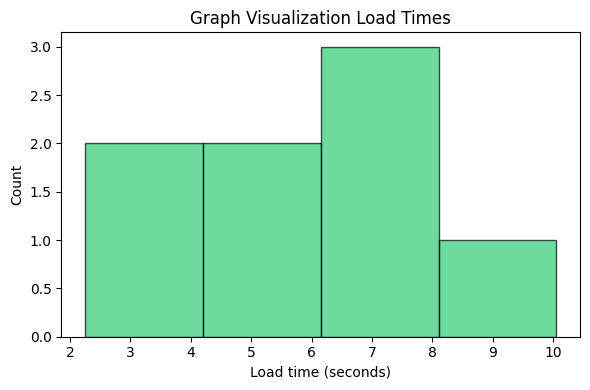

In [772]:
if not loading_times:
    print("No graph load times to display (filtered_df may be empty).")
else:
    load_times_sec = [ms / 1000 for _, _, ms in loading_times]
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(load_times_sec, bins='auto', color='#2ecc71', edgecolor='black', alpha=0.7)
    ax.set_xlabel('Load time (seconds)')
    ax.set_ylabel('Count')
    ax.set_title('Graph Visualization Load Times')
    plt.tight_layout()
    plt.show()

## 5. Aggregate by Condition and Create Bar Charts

Two bar charts: **Accuracy** (list vs graph) and **Mean time per question** (list vs graph), with loading time subtracted for graph.

In [773]:
def sem_proportion(p, n):
    if n <= 0: return 0
    return np.sqrt(p * (1 - p) / n)

def sem_mean(x):
    n = len(x)
    return stats.sem(x) if n > 1 else 0

summary = answers_df.groupby('condition').agg(
    accuracy=('correct', 'mean'),
    sem_accuracy=('correct', lambda x: sem_proportion(x.mean(), len(x))),
    mean_time_sec=('timeMs_net', lambda x: x.mean() / 1000),
    sem_time_sec=('timeMs_net', lambda x: sem_mean(x.values / 1000)),
    count=('correct', 'count'),
).reset_index()

print("Summary by condition:")
print(summary.to_string(index=False))
print()

Summary by condition:
condition  accuracy  sem_accuracy  mean_time_sec  sem_time_sec  count
    graph     0.375      0.171163      15.106088      1.596266      8
     list     0.200      0.178885      69.469800     29.026041      5



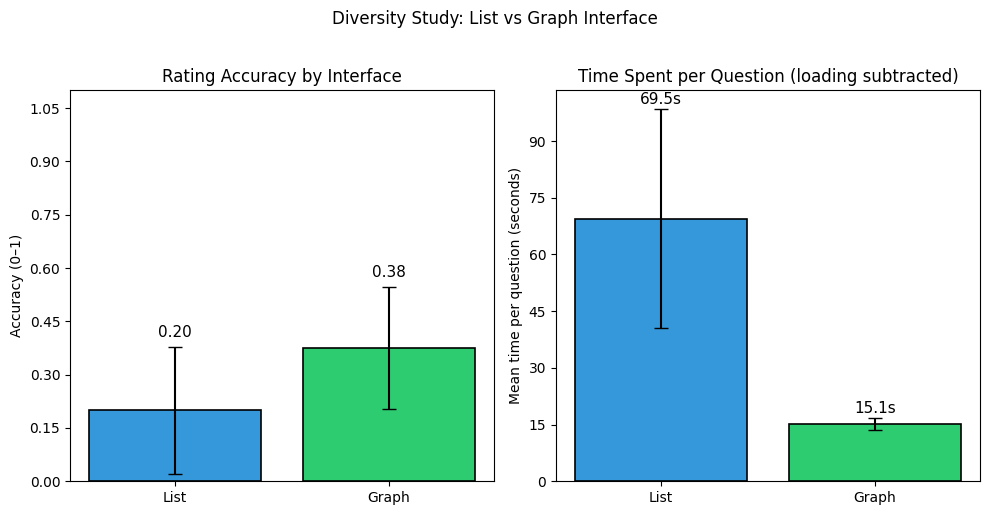

In [774]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Order: list, graph
conditions = ['list', 'graph']
labels = ['List', 'Graph']
colors = ['#3498db', '#2ecc71']

def get_val(summary_df, cond, col, default=0):
    s = summary_df[summary_df['condition'] == cond][col]
    return float(s.iloc[0]) if len(s) > 0 else default

# Bar chart 1: Accuracy
ax1 = axes[0]
acc_data = [get_val(summary, c, 'accuracy', 0) for c in conditions]
acc_err = [get_val(summary, c, 'sem_accuracy', 0) for c in conditions]
bars1 = ax1.bar(labels, acc_data, yerr=acc_err, color=colors, edgecolor='black', linewidth=1.2, capsize=5)
ax1.set_ylabel('Accuracy (0–1)')
ax1.set_title('Rating Accuracy by Interface')
ax1.set_ylim(0, 1.1)
ax1.yaxis.set_major_locator(plt.MaxNLocator(integer=False))
for bar, val, err in zip(bars1, acc_data, acc_err):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + err + 0.02, f'{val:.2f}', ha='center', va='bottom', fontsize=11)

# Bar chart 2: Mean time (seconds)
ax2 = axes[1]
time_data = [get_val(summary, c, 'mean_time_sec', 0) for c in conditions]
time_err = [get_val(summary, c, 'sem_time_sec', 0) for c in conditions]
bars2 = ax2.bar(labels, time_data, yerr=time_err, color=colors, edgecolor='black', linewidth=1.2, capsize=5)
ax2.set_ylabel('Mean time per question (seconds)')
ax2.set_title('Time Spent per Question (loading subtracted)')
ax2.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
for bar, val, err in zip(bars2, time_data, time_err):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + err + 0.5, f'{val:.1f}s', ha='center', va='bottom', fontsize=11)

plt.suptitle('Diversity Study: List vs Graph Interface', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

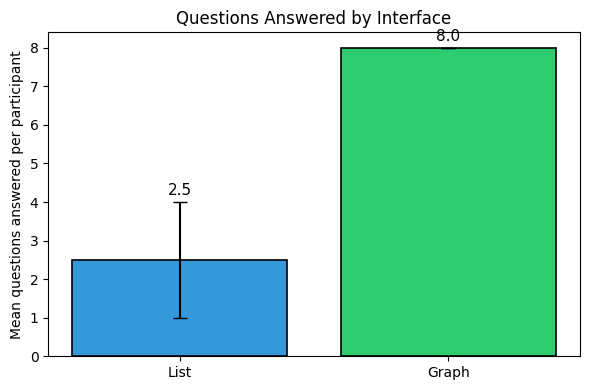

In [775]:
# Number of questions answered per interface (mean per participant ± SEM)
per_participant = answers_df.groupby(['participant_id', 'condition']).size().reset_index(name='count')
count_data = []
count_err = []
for c in conditions:
    vals = per_participant[per_participant['condition'] == c]['count'].values
    count_data.append(float(np.mean(vals)) if len(vals) > 0 else 0)
    count_err.append(float(stats.sem(vals)) if len(vals) > 1 else 0)
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, count_data, yerr=count_err, color=colors, edgecolor='black', linewidth=1.2, capsize=5)
ax.set_ylabel('Mean questions answered per participant')
ax.set_title('Questions Answered by Interface')
for bar, val, err in zip(bars, count_data, count_err):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + err + 0.1, f'{val:.1f}', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

### 5.5 Accuracy by Question Index

Accuracy for each question index, by interface (list vs graph).

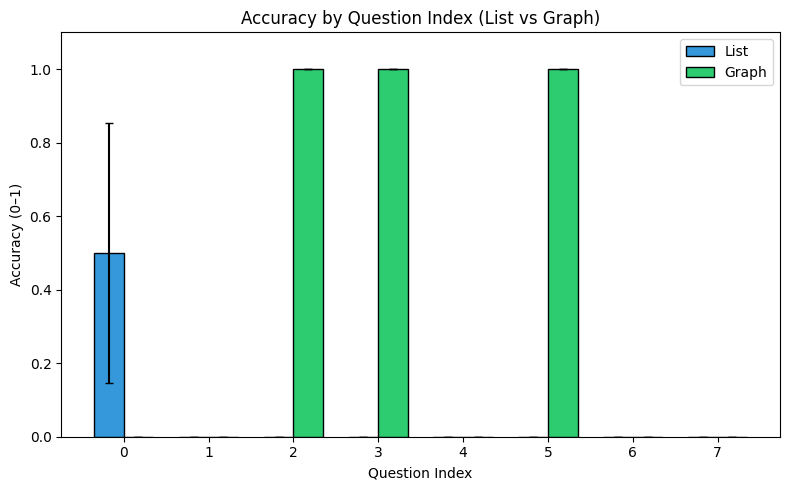

In [776]:
# Accuracy by question index for both interfaces (sem_proportion from summary cell)
by_q = answers_df.groupby(['questionIndex', 'condition']).agg(
    accuracy=('correct', 'mean'),
    sem=('correct', lambda x: sem_proportion(x.mean(), len(x))),
    count=('correct', 'count'),
).reset_index()

# Pivot for grouped bar chart
pivot = by_q.pivot(index='questionIndex', columns='condition', values='accuracy').reindex(columns=['list', 'graph'])
pivot = pivot.fillna(0)
pivot_sem = by_q.pivot(index='questionIndex', columns='condition', values='sem').reindex(columns=['list', 'graph']).reindex(pivot.index).fillna(0)

x = np.arange(len(pivot))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, pivot['list'], width, yerr=pivot_sem['list'].values, label='List', color='#3498db', edgecolor='black', capsize=3)
bars2 = ax.bar(x + width/2, pivot['graph'], width, yerr=pivot_sem['graph'].values, label='Graph', color='#2ecc71', edgecolor='black', capsize=3)

ax.set_xlabel('Question Index')
ax.set_ylabel('Accuracy (0–1)')
ax.set_title('Accuracy by Question Index (List vs Graph)')
ax.set_xticks(x)
ax.set_xticklabels(pivot.index)
ax.legend()
ax.set_ylim(0, 1.1)
ax.set_yticks(np.linspace(0, 1, 6))
plt.tight_layout()
plt.show()

### 5.6 Accuracy by Lower Temperature

Accuracy bucketed by the **lower** of the two temperature values (temp1, temp2) for each question, by interface.

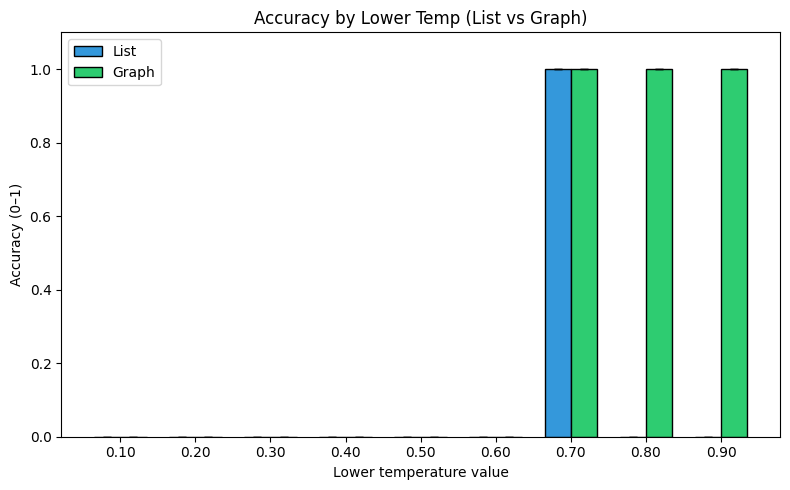

In [777]:
# Accuracy by lower temp for both interfaces (drop rows missing temp; sem_proportion from summary cell)
df_temp = answers_df.dropna(subset=['lower_temp']).copy()
if len(df_temp) == 0:
    print("No answers with temp1/temp2 — cannot plot accuracy by lower temp.")
else:
    by_lt = df_temp.groupby(['lower_temp', 'condition']).agg(
        accuracy=('correct', 'mean'),
        sem=('correct', lambda x: sem_proportion(x.mean(), len(x))),
        count=('correct', 'count'),
    ).reset_index()

    pivot_lt = by_lt.pivot(index='lower_temp', columns='condition', values='accuracy').reindex(columns=['list', 'graph'])
    pivot_lt = pivot_lt.fillna(0)
    pivot_lt_sem = by_lt.pivot(index='lower_temp', columns='condition', values='sem').reindex(columns=['list', 'graph']).reindex(pivot_lt.index).fillna(0)
    pivot_lt.index = [f"{x:.2f}" for x in pivot_lt.index]

    x = np.arange(len(pivot_lt))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))
    bars1 = ax.bar(x - width/2, pivot_lt['list'], width, yerr=pivot_lt_sem['list'].values, label='List', color='#3498db', edgecolor='black', capsize=3)
    bars2 = ax.bar(x + width/2, pivot_lt['graph'], width, yerr=pivot_lt_sem['graph'].values, label='Graph', color='#2ecc71', edgecolor='black', capsize=3)

    ax.set_xlabel('Lower temperature value')
    ax.set_ylabel('Accuracy (0–1)')
    ax.set_title('Accuracy by Lower Temp (List vs Graph)')
    ax.set_xticks(x)
    ax.set_xticklabels(pivot_lt.index)
    ax.legend()
    ax.set_ylim(0, 1.1)
    ax.set_yticks(np.linspace(0, 1, 6))
    plt.tight_layout()
    plt.show()

## 6. Participant Timelines

Horizontal stacked bar charts showing each participant's study timeline: intro, enter task page, open+load vis, looking at vis, answering (correct/incorrect), block transitions, and final survey.

In [778]:
def flatten_events(df_subset):
    """Flatten all telemetry events from df_subset. Deduplicate by (pid, type, timestamp, key)."""
    events = []
    seen = set()
    for _, row in df_subset.iterrows():
        pid = str(row.get('Participant ID', '')).strip() if pd.notna(row.get('Participant ID')) else ''
        if not pid:
            continue
        telemetry = safe_parse_json(row.get('Telemetry', ''))
        if not telemetry:
            continue
        interface = row.get('Interface', '')
        for evt in telemetry:
            ts = evt.get('timestamp')
            if ts is None:
                continue
            evt_type = evt.get('type')
            data = evt.get('data', {})
            key = (pid, evt_type, ts, data.get('url', ''), data.get('block'), data.get('questionIndex'))
            if key in seen:
                continue
            seen.add(key)
            events.append({'pid': pid, 'ts': ts, 'type': evt_type, 'data': data, 'interface': interface})
    return events

def build_timeline_segments(events_list):
    """
    Build timeline segments from ordered events.
    Returns: dict participant_id -> list of (segment_type, duration_s, correct?, visType)
    where correct? is True/False for answer segments, None otherwise;
    visType is 'graph'|'raw_outputs' for open_load, looking, answer; None otherwise.
    """
    from collections import defaultdict
    events_by_pid = defaultdict(list)
    for e in events_list:
        events_by_pid[e['pid']].append(e)
    
    result = {}
    for pid, evts in events_by_pid.items():
        evts = sorted(evts, key=lambda x: (x['ts'], x['type']))
        segs = []
        
        landing_load_ts = None
        answers = []
        vis_events = []
        
        for e in evts:
            if e['interface'] == 'landing_page_diversity' and e['type'] == 'page_load':
                url = e['data'].get('url', '')
                if 'landing_page_diversity' in url and landing_load_ts is None:
                    landing_load_ts = e['ts']
            elif e['type'] == 'diversity_comparison_answer':
                answers.append({
                    'ts': e['ts'], 'block': e['data'].get('block'), 'qix': e['data'].get('questionIndex'),
                    'correct': e['data'].get('correct', False), 'timeMs': e['data'].get('timeMs', 0),
                    'url': e['data'].get('url', ''),
                    'visType': e['data'].get('visType') or 'graph'
                })
            elif e['interface'] in ('graph', 'raw_outputs'):
                vis_events.append({
                    'ts': e['ts'], 'type': e['type'], 'url': e['data'].get('url', ''),
                    'interface': e['interface'], 'data': e['data']
                })
        
        if not landing_load_ts:
            result[pid] = segs
            continue
        
        answers = sorted(answers, key=lambda a: (a['block'], a['qix']))
        
        def url_match(a_url, v_url):
            if not a_url or not v_url:
                return False
            a_norm = a_url.replace('%2C', ',')
            v_norm = v_url.replace('%2C', ',')
            return a_norm == v_norm or (a_norm in v_norm) or (v_norm in a_norm)
        
        prev_ts = landing_load_ts
        last_block1_ts = None
        first_block2_q_load = None
        
        for i, a in enumerate(answers):
            block = a['block']
            q_load_ts = a['ts'] - a['timeMs']
            ans_ts = a['ts']
            url = a.get('url', '')
            
            if i == 0:
                dur = (q_load_ts - prev_ts) / 1000.0
                if dur > 0 and dur < 3600:
                    segs.append(('intro', dur, None, None))
                prev_ts = q_load_ts
            
            vis_for_url = [v for v in vis_events if url_match(url, v.get('url', ''))]
            vis_for_url = sorted(vis_for_url, key=lambda x: x['ts'])
            
            vis_page_load = next((v for v in vis_for_url if v['type'] == 'page_load'), None)
            if vis_page_load:
                enter_dur = (vis_page_load['ts'] - prev_ts) / 1000.0
                if enter_dur > 0 and enter_dur < 300:
                    vtype = vis_page_load.get('interface') or 'graph'
                    segs.append(('enter_task', enter_dur, None, vtype))
                prev_ts = vis_page_load['ts']
                
                load_done_ts = vis_page_load['ts']
                if vis_page_load['interface'] == 'graph':
                    loaded = next((v for v in vis_for_url if v['type'] == 'graph_vis_loaded'), None)
                    if loaded:
                        load_done_ts = vis_page_load['ts'] + loaded['data'].get('timeSincePageLoadMs', 0)
                else:
                    list_loaded = next((v for v in vis_for_url if v['type'] == 'list_vis_loaded'), None)
                    if list_loaded:
                        load_done_ts = vis_page_load['ts'] + list_loaded['data'].get('timeSincePageLoadMs', 0)
                
                load_dur = (load_done_ts - prev_ts) / 1000.0
                if load_dur > 0:
                    vtype = vis_page_load.get('interface') or 'graph'
                    segs.append(('open_load', load_dur, None, vtype))
                prev_ts = load_done_ts
                
                leave = next((v for v in vis_for_url if v['type'] == 'leavePage'), None)
                if leave:
                    look_dur = (leave['ts'] - prev_ts) / 1000.0
                    if look_dur > 0:
                        vtype = vis_page_load.get('interface') or 'graph'
                        segs.append(('looking', look_dur, None, vtype))
                    prev_ts = leave['ts']
                else:
                    prev_ts = ans_ts - 1000
            
            ans_dur = max(0.1, (ans_ts - prev_ts) / 1000.0)
            vtype = a.get('visType') or 'graph'
            segs.append(('answer', ans_dur, a['correct'], vtype))
            prev_ts = ans_ts
            
            if block == 1:
                last_block1_ts = ans_ts
            elif block == 2:
                if first_block2_q_load is None:
                    first_block2_q_load = q_load_ts
                    if last_block1_ts and first_block2_q_load > last_block1_ts:
                        trans_dur = (first_block2_q_load - last_block1_ts) / 1000.0
                        if trans_dur > 0 and trans_dur < 600:
                            segs.append(('block_transition', trans_dur, None, None))
        
        segs.append(('final_survey', 60.0, None, None))
        result[pid] = segs
    
    return result

In [779]:
# Gray: intro, block_transition, final_survey
SEGMENT_COLORS = {
    'intro': '#bdc3c7',           # gray
    'enter_task': None,            # interface-specific
    'open_load': None,             # interface-specific
    'looking': None,               # interface-specific
    'answer': None,
    'block_transition': '#bdc3c7', # gray
    'final_survey': '#5d6d7e',    # dark gray
}
# Graph = yellow family; List = blue family; enter_task = light gray for both
GRAPH_COLORS = {'enter_task': '#e0e0e0', 'open_load': '#fff8e1', 'looking': '#ffecb3'}  # light gray, soft cream, soft yellow
LIST_COLORS = {'enter_task': '#e0e0e0', 'open_load': '#b3e5fc', 'looking': '#2196f3'}    # light gray, light blue, blue
ANSWER_CORRECT = '#27ae60'
ANSWER_INCORRECT = '#e74c3c'

events_flat = flatten_events(filtered_df)
events_flat = [e for e in events_flat if e['ts'] <= end_ts_by_pid.get(e['pid'], float('inf'))]
timeline_segments = build_timeline_segments(events_flat)

### Event Dots Timeline (Vega-Lite)

Key events as dots on a timeline—one row per participant. Events: opening page, loading vis (graph/list), answering (green=correct, red=incorrect), leaving page, block/task change. Hover over dots for details.  
*(Requires `pip install altair` if not installed.)*

In [780]:
# Build event-dots data for Vega-Lite (filtered key events: page open, vis load, answers, page/task changes)
import altair as alt
from IPython.display import display

# Only these event types (opening page, loading vis, answering, changing pages/tasks)
EVENT_TYPES_KEEP = {
    'page_load',
    'graph_vis_loaded', 'list_vis_loaded',
    'diversity_comparison_answer',
    'leavePage', 'block_timer_elapsed',
}

def event_display_type(e):
    """Display label for event; answers split by accuracy for color coding."""
    if e['type'] == 'diversity_comparison_answer':
        correct = e.get('data', {}).get('correct', False)
        return 'Answer (correct)' if correct else 'Answer (incorrect)'
    if e['type'] == 'page_load':
        iface = (e.get('interface') or '').lower()
        return 'Open page (graph)' if 'graph' in iface else ('Open page (list)' if 'list' in iface or 'raw' in iface else 'Open page')
    label_map = {
        'graph_vis_loaded': 'Load vis (graph)',
        'list_vis_loaded': 'Load vis (list)',
        'leavePage': 'Leave page',
        'block_timer_elapsed': 'Block / task change',
    }
    return label_map.get(e['type'], e['type'])

def event_tooltip_info(e):
    """Build tooltip string from event data."""
    d = e.get('data', {})
    parts = []
    if e['type'] == 'diversity_comparison_answer':
        parts.append(f"correct={d.get('correct')}")
        parts.append(f"timeMs={d.get('timeMs')}")
        parts.append(f"visType={d.get('visType', 'graph')}")
        if d.get('block') is not None:
            parts.append(f"block={d.get('block')}")
        if d.get('questionIndex') is not None:
            parts.append(f"q={d.get('questionIndex')}")
    elif e['type'] in ('graph_vis_loaded', 'list_vis_loaded'):
        parts.append(f"loadMs={d.get('timeSincePageLoadMs')}")
    elif e['type'] == 'page_load':
        url = (d.get('url') or '')[:60]
        if len(d.get('url') or '') > 60:
            url += '...'
        parts.append(f"url={url}")
    return '; '.join(parts) if parts else ''

# Get events, filter to key types, compute relative time (t=0 per participant = first app open)
evts_all = flatten_events(filtered_df)
evts = [e for e in evts_all if e['type'] in EVENT_TYPES_KEEP]

# Filter events to those before participant left for Prolific (end_ts_by_pid from earlier cell)
evts = [e for e in evts if e['ts'] <= end_ts_by_pid.get(e['pid'], float('inf'))]

if not evts:
    print("No events to plot.")
else:
    # Per-participant t0 = first event (when they opened the app)
    t0_by_pid = {}
    for e in evts:
        pid = e['pid']
        if pid not in t0_by_pid or e['ts'] < t0_by_pid[pid]:
            t0_by_pid[pid] = e['ts']
    rows = []
    for e in evts:
        rows.append({
            'pid': e['pid'],
            'time_s': (e['ts'] - t0_by_pid[e['pid']]) / 1000.0,
            'display_type': event_display_type(e),
            'interface': e.get('interface', ''),
            'tooltip': event_tooltip_info(e),
        })
    events_dots_df = pd.DataFrame(rows)
    
    # Compute time_s_end = start of next event (bar extends until next event or study end)
    events_dots_df = events_dots_df.sort_values(['pid', 'time_s'])
    events_dots_df['time_s_end'] = events_dots_df.groupby('pid')['time_s'].shift(-1)
    # For last event: use study end time if participant left from final stage, else +10s
    for pid in events_dots_df['pid'].unique():
        mask = events_dots_df['pid'] == pid
        last_mask = mask & events_dots_df['time_s_end'].isna()
        if last_mask.any() and pid in end_ts_by_pid:
            end_s = (end_ts_by_pid[pid] - t0_by_pid[pid]) / 1000.0
            events_dots_df.loc[last_mask, 'time_s_end'] = end_s
        else:
            events_dots_df.loc[last_mask, 'time_s_end'] = events_dots_df.loc[last_mask, 'time_s'] + 10
    
    # Order display types: Open page (graph/list), Load vis, Answer correct, Answer incorrect, Leave page, Block change
    type_order = ['Open page (graph)', 'Open page (list)', 'Open page', 'Load vis (graph)', 'Load vis (list)', 'Answer (correct)', 'Answer (incorrect)', 'Leave page', 'Block / task change']
    # Custom colors: Open page by vis type, load vis unchanged, green=correct, red=incorrect, gray=page/task
    type_colors = {
        'Open page (graph)': '#fef9c3',
        'Open page (list)': '#bbdefb',
        'Open page': '#95a5a6',
        'Load vis (graph)': '#f1c40f',
        'Load vis (list)': '#3498db',
        'Answer (correct)': '#27ae60',
        'Answer (incorrect)': '#e74c3c',
        'Leave page': '#7f8c8d',
        'Block / task change': '#34495e',
    }
    
    # Sort participants for consistent y-order (by first event time)
    pid_order = events_dots_df.groupby('pid')['time_s'].min().sort_values().index.tolist()
    events_dots_df['pid'] = pd.Categorical(events_dots_df['pid'], categories=pid_order, ordered=True)
    
    base_chart = alt.Chart(events_dots_df).mark_rect(opacity=0.8).encode(
        x=alt.X('time_s:Q', title='Time (seconds from first app open)'),
        x2=alt.X2('time_s_end:Q'),
        y=alt.Y('pid:N', title='Participant', sort=pid_order, scale=alt.Scale(paddingInner=0.2)),
        color=alt.Color('display_type:N', title='Event type', scale=alt.Scale(
            domain=list(type_colors.keys()),
            range=list(type_colors.values())
        )),
        tooltip=[
            alt.Tooltip('display_type:N', title='Type'),
            alt.Tooltip('interface:N', title='Interface'),
            alt.Tooltip('time_s:Q', title='Time (s)', format='.1f'),
            alt.Tooltip('tooltip:N', title='Details'),
        ],
    ).properties(
        width=700,
        height=max(200, len(pid_order) * 40),
        title='Key Events by Participant (page open, vis load, answers, page/task changes)'
    ).interactive()
    
    display(base_chart)

alt.Chart(...)

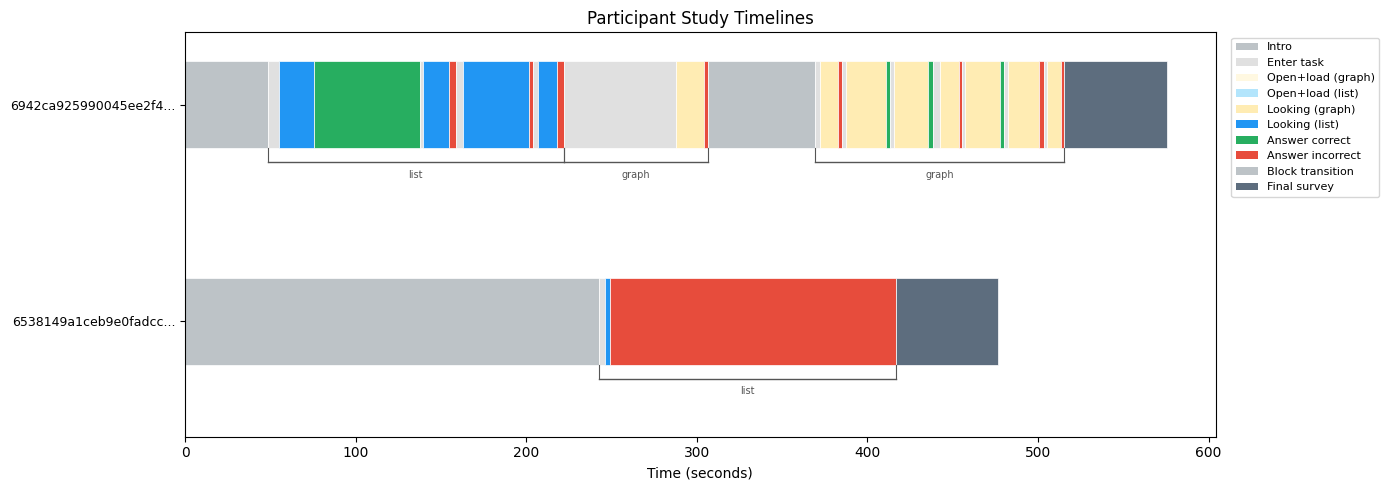

In [781]:
# Plot: one horizontal stacked bar per participant
participants = sorted([p for p in timeline_segments if timeline_segments[p]])
if not participants:
    print("No participants with timeline segments.")
else:
    n = len(participants)
    row_spacing = 1.5
    fig, ax = plt.subplots(figsize=(14, max(5, n * row_spacing * 0.5)))
    
    y_pos = np.arange(n) * row_spacing
    bar_height = 0.6
    label_offset = 0.05
    for i, pid in enumerate(participants):
        segs = timeline_segments[pid]
        left = 0
        seg_records = []  # (left, dur, seg_type, visType) for labels
        for seg in segs:
            seg_type = seg[0]
            dur = seg[1]
            correct = seg[2] if len(seg) > 2 else None
            visType = seg[3] if len(seg) > 3 else None
            if dur <= 0:
                continue
            color = SEGMENT_COLORS.get(seg_type)
            hatch = ''
            if seg_type == 'answer':
                color = ANSWER_CORRECT if correct else ANSWER_INCORRECT
                hatch = ''
            elif seg_type in ('enter_task', 'open_load', 'looking') and visType:
                if visType == 'graph':
                    color = GRAPH_COLORS.get(seg_type)
                else:
                    color = LIST_COLORS.get(seg_type)
            if color is None:
                color = '#95a5a6'
            
            ax.barh(y_pos[i], dur, left=left, height=bar_height, color=color, hatch=hatch, edgecolor='white', linewidth=0.5)
            seg_records.append((left, dur, seg_type, visType))
            left += dur
        
        y_center = y_pos[i]
        y_bottom = y_center - bar_height / 2
        
        runs = []  # (start_x, end_x, interface)
        run_start, run_iface = None, None
        for l, d, st, vt in seg_records:
            iface = 'graph' if vt == 'graph' else ('list' if vt == 'raw_outputs' else None)
            if iface and st in ('enter_task', 'open_load', 'looking', 'answer'):
                if iface == run_iface:
                    runs[-1] = (runs[-1][0], l + d, iface)
                else:
                    runs.append((l, l + d, iface))
                    run_iface = iface
            else:
                run_iface = None
        for start_x, end_x, iface in runs:
            w = end_x - start_x
            if w < 1:
                continue
            bracket_y = y_bottom - label_offset * 2  # same level for all runs
            ax.plot([start_x, end_x], [bracket_y, bracket_y], color='#555', linewidth=1)
            ax.plot([start_x, start_x], [y_bottom, bracket_y], color='#555', linewidth=0.8)
            ax.plot([end_x, end_x], [y_bottom, bracket_y], color='#555', linewidth=0.8)
            ax.text((start_x + end_x) / 2, bracket_y - label_offset, iface, ha='center', va='top', fontsize=7, color='#555')
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels([p[:20] + '...' if len(p) > 20 else p for p in participants], fontsize=9)
    ax.set_ylim(-0.8, (n - 1) * row_spacing + 0.5)  # room for graph/list labels below bars
    ax.set_xlabel('Time (seconds)')
    ax.set_title('Participant Study Timelines')
    
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=SEGMENT_COLORS['intro'], label='Intro'),
        Patch(facecolor=GRAPH_COLORS['enter_task'], label='Enter task'),
        Patch(facecolor=GRAPH_COLORS['open_load'], label='Open+load (graph)'),
        Patch(facecolor=LIST_COLORS['open_load'], label='Open+load (list)'),
        Patch(facecolor=GRAPH_COLORS['looking'], label='Looking (graph)'),
        Patch(facecolor=LIST_COLORS['looking'], label='Looking (list)'),
        Patch(facecolor=ANSWER_CORRECT, label='Answer correct'),
        Patch(facecolor=ANSWER_INCORRECT, label='Answer incorrect'),
        Patch(facecolor=SEGMENT_COLORS['block_transition'], label='Block transition'),
        Patch(facecolor=SEGMENT_COLORS['final_survey'], label='Final survey'),
    ]
    ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=8)
    plt.tight_layout()
    plt.show()